# Генерация анекдотов: BPE + LSTM

Улучшенная версия ноутбука с лекции. Основные изменения:

1. **BPE-токенизация** вместо посимвольной — короче последовательности, осмысленные эмбеддинги
2. **Честный EOS** — модель учится заканчивать анекдот, а не обрывается по max_len
3. **Tied embeddings** — экономия параметров и регуляризация
4. **Gradient clipping** — стабильность обучения
5. **Label smoothing** — меньше переуверенности
6. **Scheduler + меньший lr** — лучше сходимость
7. **Mixed precision (AMP)** — быстрее обучение
8. **Top-p sampling + repetition penalty** — заметно лучше качество генерации
9. **Early stopping** по valid loss

## Установка и импорты

In [1]:
!pip install tokenizers -q

In [2]:
import os
import random
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn.utils.rnn import pad_sequence
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.cuda.amp import autocast, GradScaler

import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm.auto import tqdm

from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import ByteLevel as BLPre
from tokenizers.decoders import ByteLevel as BLDec

# Воспроизводимость
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name())

Device: cuda:0
GPU: Tesla T4


## Данные

In [3]:
DATA_PATH = '/kaggle/input/datasets/artembez/anekdotes/anek.txt'

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    aneks = f.read().split('\n')

# Лёгкая чистка: убираем пустые строки и обрезаем пробелы
aneks = [a.strip() for a in aneks if a.strip()]

print(f'Всего анекдотов: {len(aneks)}')
print(f'Пример: {aneks[10]!r}')
print(f'Средняя длина в символах: {sum(len(a) for a in aneks) / len(aneks):.1f}')

Всего анекдотов: 125102
Пример: 'Штирлиц топил буржуйку. Только через два часа ему удалось ее утопить.'
Средняя длина в символах: 110.4


## Обучение BPE-токенизатора

Используем `ByteLevel` — он корректно обрабатывает любые символы и гарантирует точное восстановление текста. Визуально токены будут выглядеть странно (`Ð¨ÑĤÐ¸` вместо `Шти`), но это только отображение — `decode()` вернёт нормальный русский.

In [4]:
VOCAB_SIZE = 8000
TOKENIZER_PATH = 'bpe_aneks.json'

tokenizer = Tokenizer(BPE(unk_token='<unk>'))
tokenizer.pre_tokenizer = BLPre(add_prefix_space=True)
tokenizer.decoder = BLDec()

trainer = BpeTrainer(
    vocab_size=VOCAB_SIZE,
    special_tokens=['<pad>', '<sos>', '<eos>', '<unk>'],
    min_frequency=2,
    show_progress=True,
    initial_alphabet=BLPre.alphabet(),
)

tokenizer.train_from_iterator(aneks, trainer=trainer)
tokenizer.save(TOKENIZER_PATH)
print(f'Реальный размер словаря: {tokenizer.get_vocab_size()}')




Реальный размер словаря: 8000


In [5]:
# Спецтокены и индексы
PAD_ID = tokenizer.token_to_id('<pad>')
SOS_ID = tokenizer.token_to_id('<sos>')
EOS_ID = tokenizer.token_to_id('<eos>')
VOCAB_SIZE = tokenizer.get_vocab_size()

print(f'PAD={PAD_ID}, SOS={SOS_ID}, EOS={EOS_ID}, VOCAB={VOCAB_SIZE}')

# Проверка: что декодирование корректно восстанавливает текст
sample = aneks[10]
ids = tokenizer.encode(sample).ids
restored = tokenizer.decode(ids)
print(f'\nИсходный:     {sample!r}')
print(f'Число токенов: {len(ids)} (символов: {len(sample)})')
print(f'Восстановлен: {restored!r}')

PAD=0, SOS=1, EOS=2, VOCAB=8000

Исходный:     'Штирлиц топил буржуйку. Только через два часа ему удалось ее утопить.'
Число токенов: 19 (символов: 69)
Восстановлен: ' Штирлиц топил буржуйку. Только через два часа ему удалось ее утопить.'


In [6]:
# Статистика длин в токенах — пригодится для выбора max_len
lengths = [len(tokenizer.encode(a).ids) for a in aneks[:5000]]
print(f'Длина в токенах: mean={sum(lengths)/len(lengths):.1f}, '
      f'max={max(lengths)}, p95={sorted(lengths)[int(len(lengths)*0.95)]}, '
      f'p99={sorted(lengths)[int(len(lengths)*0.99)]}')

Длина в токенах: mean=32.6, max=292, p95=65, p99=91


## Dataset и DataLoader

In [7]:
MAX_LEN = 128  # в BPE-токенах; покрывает ~95% анекдотов целиком

class Anekdotes(Dataset):
    def __init__(self, aneks, tokenizer, max_len=MAX_LEN):
        self.aneks = aneks
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.aneks)

    def __getitem__(self, idx):
        ids = self.tokenizer.encode(self.aneks[idx]).ids
        # Обрезаем с запасом на SOS/EOS
        ids = ids[:self.max_len - 2]
        ids = [SOS_ID] + ids + [EOS_ID]
        return torch.LongTensor(ids)

dataset = Anekdotes(aneks, tokenizer)
print('Пример:', dataset[10][:20].tolist(), '...')

Пример: [1, 1014, 2813, 328, 5370, 413, 783, 408, 17, 1328, 1176, 817, 2241, 856, 3163, 705, 1631, 426, 388, 17] ...


In [8]:
# Разбиение с фиксированным seed для воспроизводимости
n_train = int(len(dataset) * 0.95)
n_valid = len(dataset) - n_train
train_dataset, valid_dataset = random_split(
    dataset, [n_train, n_valid],
    generator=torch.Generator().manual_seed(SEED)
)
print(f'Train: {len(train_dataset)}, Valid: {len(valid_dataset)}')

Train: 118846, Valid: 6256


In [9]:
def collate_fn(batch):
    return pad_sequence(batch, padding_value=PAD_ID, batch_first=True)

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate_fn, pin_memory=True, num_workers=2, drop_last=True,
)
valid_loader = DataLoader(
    valid_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_fn, pin_memory=True, num_workers=2,
)

# Проверка формы
batch = next(iter(train_loader))
print('Batch shape:', batch.shape)

Batch shape: torch.Size([128, 103])


## Модель

LSTM с tied embeddings: вес выходного линейного слоя привязан к матрице эмбеддингов. Это требует `emb_size == hidden_size`, зато экономит `VOCAB_SIZE × hidden_size` параметров и работает как регуляризация.

In [10]:
class AnekdotesLSTM(nn.Module):
    def __init__(self, vocab_size, hidden_size=384, num_layers=2,
                 dropout=0.3, pad_id=0, tie_weights=True):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, hidden_size, padding_idx=pad_id)
        self.emb_dropout = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )

        self.out_dropout = nn.Dropout(dropout)
        self.head = nn.Linear(hidden_size, vocab_size)

        # tied embeddings
        if tie_weights:
            self.head.weight = self.embedding.weight

        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.embedding.weight, mean=0.0, std=0.02)
        nn.init.zeros_(self.head.bias)
        # Ортогональная инициализация рекуррентных весов — помогает LSTM
        for name, p in self.lstm.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(p)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(p)
            elif 'bias' in name:
                nn.init.zeros_(p)
                # forget gate bias = 1 (стандартная эвристика для LSTM)
                n = p.size(0)
                p.data[n//4:n//2].fill_(1.0)

    def forward(self, x, hidden=None):
        emb = self.emb_dropout(self.embedding(x))
        out, hidden = self.lstm(emb, hidden)
        out = self.out_dropout(out)
        logits = self.head(out)
        return logits, hidden

In [11]:
HIDDEN_SIZE = 384
NUM_LAYERS = 2
DROPOUT = 0.3

model = AnekdotesLSTM(
    vocab_size=VOCAB_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    pad_id=PAD_ID,
    tie_weights=True,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Параметров: {n_params/1e6:.2f}M')

Параметров: 5.45M


## Обучение

- **Label smoothing 0.1** — снижает переуверенность модели
- **Gradient clipping 1.0** — обязательно для RNN, чтобы не было взрыва градиентов
- **AdamW** с `lr=1e-3` и `weight_decay=0.01`
- **Cosine scheduler** по шагам
- **Mixed precision** — ускорение в ~2 раза

In [16]:
NUM_EPOCHS = 10
LR = 1e-3
WEIGHT_DECAY = 0.01
GRAD_CLIP = 1.0
LABEL_SMOOTHING = 0.1
PATIENCE = 4  # для early stopping

loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_ID, label_smoothing=LABEL_SMOOTHING)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

total_steps = NUM_EPOCHS * len(train_loader)
scheduler = CosineAnnealingLR(optimizer, T_max=total_steps, eta_min=1e-5)

use_amp = torch.cuda.is_available()
scaler = GradScaler(enabled=use_amp)

/tmp/ipykernel_189/1046813706.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=use_amp)


In [17]:
def train_epoch(model, loader, optimizer, scheduler, scaler, loss_fn,
                 clip=GRAD_CLIP, use_amp=True):
    model.train()
    total_loss = 0.0
    total_tokens = 0

    pbar = tqdm(loader, desc='Train', leave=False)
    for batch in pbar:
        batch = batch.to(device, non_blocking=True)
        inputs = batch[:, :-1]
        targets = batch[:, 1:]

        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=use_amp):
            logits, _ = model(inputs)
            loss = loss_fn(logits.reshape(-1, logits.size(-1)),
                           targets.reshape(-1))

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        n_tokens = (targets != PAD_ID).sum().item()
        total_loss += loss.item() * n_tokens
        total_tokens += n_tokens

        pbar.set_postfix(loss=f'{loss.item():.3f}',
                         lr=f"{optimizer.param_groups[0]['lr']:.2e}")

    return total_loss / max(total_tokens, 1)


@torch.inference_mode()
def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    for batch in tqdm(loader, desc='Valid', leave=False):
        batch = batch.to(device, non_blocking=True)
        inputs = batch[:, :-1]
        targets = batch[:, 1:]
        logits, _ = model(inputs)
        loss = loss_fn(logits.reshape(-1, logits.size(-1)),
                       targets.reshape(-1))
        n_tokens = (targets != PAD_ID).sum().item()
        total_loss += loss.item() * n_tokens
        total_tokens += n_tokens
    return total_loss / max(total_tokens, 1)

In [18]:
def plot_stats(train_hist, valid_hist, title='LSTM + BPE'):
    plt.figure(figsize=(12, 5))
    plt.plot(train_hist, label='train')
    plt.plot(valid_hist, label='valid')
    plt.title(title)
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

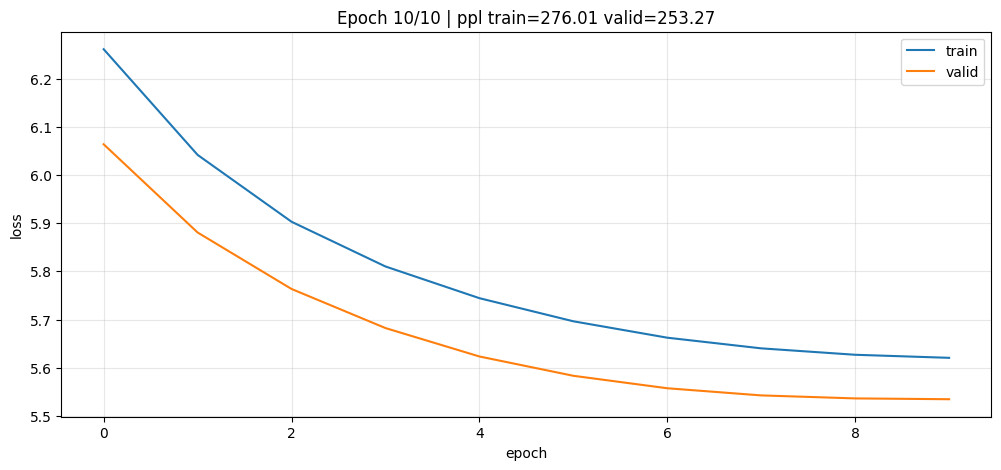

Epoch 10: train=5.6204, valid=5.5345, ppl_valid=253.27
  ↓ сохранён best checkpoint (valid=5.5345)

Загружен best checkpoint (epoch 10, valid_loss=5.5345)


In [19]:
train_hist, valid_hist = [], []
best_valid = float('inf')
best_epoch = 0
epochs_no_improve = 0
CKPT_PATH = 'best_model.pt'

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, scheduler,
                              scaler, loss_fn, use_amp=use_amp)
    valid_loss = evaluate(model, valid_loader, loss_fn)

    train_hist.append(train_loss)
    valid_hist.append(valid_loss)

    clear_output(wait=True)
    plot_stats(train_hist, valid_hist,
               f'Epoch {epoch}/{NUM_EPOCHS} | ppl train={math.exp(train_loss):.2f} '
               f'valid={math.exp(valid_loss):.2f}')
    print(f'Epoch {epoch}: train={train_loss:.4f}, valid={valid_loss:.4f}, '
          f'ppl_valid={math.exp(valid_loss):.2f}')

    if valid_loss < best_valid:
        best_valid = valid_loss
        best_epoch = epoch
        epochs_no_improve = 0
        torch.save({
            'model_state_dict': model.state_dict(),
            'epoch': epoch,
            'valid_loss': valid_loss,
        }, CKPT_PATH)
        print(f'  ↓ сохранён best checkpoint (valid={valid_loss:.4f})')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f'Early stopping на эпохе {epoch} (best epoch: {best_epoch})')
            break

# Загружаем лучший чекпойнт для генерации
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
print(f"\nЗагружен best checkpoint (epoch {ckpt['epoch']}, "
      f"valid_loss={ckpt['valid_loss']:.4f})")

## Генерация

Используем **top-p (nucleus) sampling** с **repetition penalty** — это даёт заметно более связный и разнообразный текст, чем простой sampling с температурой из оригинального ноутбука.

- `temperature` контролирует энтропию: >1 — креативнее, <1 — консервативнее
- `top_p=0.9` — отсекаем длинный хвост маловероятных токенов
- `top_k` — опциональный дополнительный фильтр
- `repetition_penalty>1` штрафует уже сгенерированные токены, борется с петлями

In [21]:
@torch.inference_mode()
def generate(model, prefix='', max_new_tokens=100,
             temperature=0.9, top_p=0.92, top_k=0,
             repetition_penalty=1.2, num_samples=1):
    model.eval()

    prefix_ids = tokenizer.encode(prefix).ids if prefix else []
    start = [SOS_ID] + prefix_ids

    results = []
    for _ in range(num_samples):
        x = torch.LongTensor([start]).to(device)
        hidden = None
        generated = list(start)

        # Первый прогон по префиксу
        logits, hidden = model(x, hidden)
        next_logits = logits[0, -1, :]

        for _ in range(max_new_tokens):
            logits_step = next_logits.clone()

            # Repetition penalty
            if repetition_penalty != 1.0:
                for tok in set(generated):
                    if tok in (SOS_ID, PAD_ID):
                        continue
                    if logits_step[tok] > 0:
                        logits_step[tok] /= repetition_penalty
                    else:
                        logits_step[tok] *= repetition_penalty

            # Температура
            logits_step = logits_step / max(temperature, 1e-6)

            # Запрет на спецтокены, кроме EOS
            logits_step[PAD_ID] = -float('inf')
            logits_step[SOS_ID] = -float('inf')

            # Top-k
            if top_k > 0:
                topk_vals, _ = torch.topk(logits_step, top_k)
                thresh = topk_vals[-1]
                logits_step[logits_step < thresh] = -float('inf')

            # Top-p (nucleus)
            if 0 < top_p < 1.0:
                sorted_logits, sorted_idx = torch.sort(logits_step, descending=True)
                probs = F.softmax(sorted_logits, dim=-1)
                cum_probs = torch.cumsum(probs, dim=-1)
                remove = cum_probs > top_p
                # Сдвигаем на 1, чтобы оставить хотя бы один токен
                remove[1:] = remove[:-1].clone()
                remove[0] = False
                to_remove = sorted_idx[remove]
                logits_step[to_remove] = -float('inf')

            probs = F.softmax(logits_step, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1).item()

            if next_id == EOS_ID:
                break

            generated.append(next_id)
            x = torch.LongTensor([[next_id]]).to(device)
            logits, hidden = model(x, hidden)
            next_logits = logits[0, -1, :]

        # Убираем SOS и декодируем
        text = tokenizer.decode(generated[1:])
        results.append(text)

    return results

In [22]:
# Генерация с разными префиксами и температурами
prefixes = [
    '',  # совсем с нуля
    'Штирлиц',
    'Приходит муж домой',
    'Поручик Ржевский',
    '- Доктор,',
]

for prefix in prefixes:
    print(f'=== Префикс: {prefix!r} ===')
    samples = generate(model, prefix=prefix, num_samples=3,
                       temperature=0.9, top_p=0.92, repetition_penalty=1.2,
                       max_new_tokens=120)
    for i, s in enumerate(samples, 1):
        print(f'  [{i}] {s}')
    print()

=== Префикс: '' ===
  [1]  Что бы ты, когда высапел в виду войны - а она либо не узнала.
  [2]  Штирлиц наконец никогда не приглядывает на все-гтооте, я скажет, что обычно мешали беременные...
  [3]  Сидят два мужика в туалете и-то вы, никуда не вызал?!

=== Префикс: 'Штирлиц' ===
  [1]  Штирлиц в городалкощенский гестро групят, а на нижнюю шлюхку, которая тошит полицейских бегов!.
  [2]  Штирлиц шел на море. Я сама понял, сколько при этом не удивился, что и занчети...
  [3]  Штирлиц пробовал до сих пор в детскийак. Американцы использованием обращенные допоя, а в чем лица запрещили войны справяется к открыт на вопросах и независимости, что он ему расизалил ампареровит.

=== Префикс: 'Приходит муж домой' ===
  [1]  Приходит муж домой, видит остановке с собой. Жена ее говорит- Маша и пей, а что ты так не везешь?
  [2]  Приходит муж домой по-пропому женщина. А как в приеме вдруг ей отвечает- А кого за такие курилы? Пусть не надо?- Тут! Нарут, что в России будут загискать свежое зима?- Да,

In [26]:
# Эксперимент с температурой: от консервативной до креативной
print('Влияние температуры:')
for temp in [0.1, 0.2, 0.3, 1.2]:
    print(f'\nT = {temp}')
    samples = generate(model, prefix='Мужик заходит в бар',
                       num_samples=2, temperature=temp, top_p=0.92,
                       repetition_penalty=1.2, max_new_tokens=100)
    for s in samples:
        print(f'  {s}')

Влияние температуры:

T = 0.1
   Мужик заходит в бар, а потом говорит- Ты что, не знаешь, что ты будешь?- Да я же не знаю.
   Мужик заходит в бар, а потом говорит- Ты что, не знаешь, что ты будешь?- Да, я же не знаю, как я не могу.

T = 0.2
   Мужик заходит в бар и говорит- Ты знаешь, что ты не хочешь?- Да, я тебе не могу.
   Мужик заходит в бар- Я хочу, чтобы я не могу найти тебя на работу.- А почему ты так думаешь?- Да, но он же не знаю.

T = 0.3
   Мужик заходит в бар-клуб. Жена говорит- Ты что, не знаешь, что ты так думаешь?- Я же не знаю, что я с тобой не могу.- А я не могу сказать, что у тебя есть?- Да нет, но как ты не можешь, чтобы я буду жить на работу.
   Мужик заходит в бар, а там на пороге. Вдруг она говорит- Ну, как ты? Я бы не могу, чтобы я буду спать!

T = 1.2
   Мужик заходит в баровой приятный мужчина, берет ложку организи в парще!. ранним желудчат- Судя гостей!Пезать видео 80 минут и заканчивается фраз пластальист Его глисты...
   Мужик заходит в бар- Нельзя сказать -

In [24]:
# Генерация пачки анекдотов с нуля для финальной оценки
print('=== 10 анекдотов, сгенерированных с нуля ===\n')
samples = generate(model, prefix='', num_samples=10,
                    temperature=0.9, top_p=0.92, repetition_penalty=1.2,
                    max_new_tokens=150)
for i, s in enumerate(samples, 1):
    print(f'{i}. {s}\n')

=== 10 анекдотов, сгенерированных с нуля ===

1.  Он с летом оставила в накваль айфона. Она сообщает свою жену- Я такая пахто, выпираю...- А кто?- Ой в моей Я же пор не женился!- А она у тебя столушку деревал?- Да! Не ебнись и возмущался, а дронка делают!?

2.  Мальчик жалуется другу- Дорогая, этот день мало как в жизни два зопиты из здоровья!- Мне мое белье!

3.  Я не хочу смотреть на половый дом, так умереть люблю только от моих!

4.  - Привет! У нас плохо, как ты могу идти и в ходе.- Да я с мамой буду пить и шубу.

5.  Я научился положить девушку с газами, а потом у техника удавать детей.

6.  - А мой ребенок в мире не получил?- На психичесце...- А вдруг одна сказала фразу туалетное со ней спасшать, что мы уденивать.

7.  - Ну, и что это у тебя проблема?- Конечно!- А если за другой лучше?- Жизнь встретились вдыхать в больницу.

8.  Стрехится в сказке. К нему подходит из гаишника- Что случилось?- Не волнуйтесь, что я проснулся о том! Даже не брава.- Это жен из армии , а вторая брева?

## Что можно попробовать дальше

Если качество всё ещё не устраивает, можно попробовать (в порядке убывания ожидаемого эффекта):

1. **Перейти на маленький Transformer** вместо LSTM — архитектура лучше подходит для языкового моделирования, при тех же ~5–10M параметров даст заметно меньший perplexity.
2. **Conditioning по жанру**: кластеризовать анекдоты (Штирлиц / поручик / муж-жена / про врачей / диалог) и подавать тип жанра как первый токен. Внутри жанра связность выше.
3. **Beam search с диверсификацией** вместо sampling, с пост-отбором по длине и наличию характерных маркеров анекдота (диалог, вопрос-ответ, завершающая точка).
4. **Re-ranking**: генерировать 20 кандидатов, отбирать лучшие по perplexity и эвристикам (есть ли панчлайн-структура, не обрывается ли на середине слова).
5. **Variational dropout / AWD-LSTM** — серьёзная регуляризация, заметно лучше стандартного dropout между слоями.